# Airplane Crash Fatality Prediction

The task is to predict `Fatalities` for a crash (a regression problem) using `airplane_crashes_data.csv`, then generate predictions for `airplane_crashes_unseen.csv`. The leaderboard metric is RMSE, so the goal throughout is minimising RMSE specifically, not maximising R² or any other metric.

Historical crash data like this is genuinely useful for aviation safety analysis. Understanding which factors (aircraft size, era, operator type) are associated with higher or lower fatality rates can inform where safety improvements matter most. Source: [Kaggle: Airplane Crashes and Fatalities](https://www.kaggle.com/datasets/thedevastator/airplane-crashes-and-fatalities).

## 1. Setup and Load

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from nltk.stem import SnowballStemmer

import warnings
warnings.filterwarnings('ignore', message="The parameter 'token_pattern' will not be used")

df = pd.read_csv("airplane_crashes_data.csv")
print(f"{df.shape[0]} rows, {df.shape[1]} columns")
df.head()

4741 rows, 13 columns


,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
0,07/12/1912,06:30,"AtlantiCity, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
1,08/06/1913,NaN,"Victoria, British Columbia, Canada",Private,-,NaN,Curtiss seaplane,NaN,NaN,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...
2,09/09/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...
3,03/05/1915,01:00,"Tienen, Belgium",Military - German Navy,NaN,NaN,Zeppelin L-8 (airship),NaN,NaN,41.0,21.0,0.0,Crashed into trees while attempting to land af...
4,09/03/1915,15:20,"Off Cuxhaven, Germany",Military - German Navy,NaN,NaN,Zeppelin L-10 (airship),NaN,NaN,19.0,19.0,0.0,"Exploded and burned near Neuwerk Island, when..."


The dataset has `Date`, `Time`, `Location`, `Route`, `Operator`, `Type`, `Registration`, `cn/In`, `Aboard`, `Fatalities`, `Ground`, and `Summary`. `Fatalities` is the target.

## 2. Data Quality Checks

In [2]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({"missing": missing, "pct": missing_pct})

,missing,pct
Flight #,3774,79.6
Time,2000,42.2
Route,1545,32.6
cn/In,1098,23.2
Summary,353,7.4
Registration,300,6.3
Type,24,0.5
Ground,20,0.4
Aboard,19,0.4
Location,17,0.4


`Flight #` is missing about 80% of the time, followed by `Time`, `Route`, and `cn/In`. These columns with a high percentage of null values are not used as features for the model. `Aboard` and `Fatalities` have only a handful of missing rows, but since one is the target and the other is needed to compute a fatality rate (see Feature Engineering below), rows missing either are dropped rather than imputed.

In [3]:
# duplicate check using the natural key of an actual crash event
print("Exact duplicate rows:", df.duplicated().sum())
print("Duplicate on [Date, Location, Operator]:", df.duplicated(subset=["Date", "Location", "Operator"]).sum())

dupes_mask = df.duplicated(subset=["Date", "Location", "Operator"], keep=False)
df[dupes_mask]

Exact duplicate rows: 0
Duplicate on [Date, Location, Operator]: 1


,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
562,11/19/1943,NaN,"Kunming, China",China National Aviation Corporation,NaN,NaN,Douglas C-53,59,NaN,3.0,2.0,0.0,The cargo plane crashed short of the runway in...
563,11/19/1943,NaN,"Kunming, China",China National Aviation Corporation,NaN,NaN,Douglas C-47,63,NaN,3.0,3.0,0.0,A navigational error caused the cargo plane to...


No exact duplicate rows, and exactly one pair sharing the same date, location, and operator. On inspection, these are two separate real crashes that happened to share all three fields by coincidence, not a data entry error, so both rows are kept.

In [4]:
# September 11, 2001 check: these rows have very large Ground values
df[df['Date'] == '09/11/2001'][['Date', 'Operator', 'Aboard', 'Fatalities', 'Ground']]

,Date,Operator,Aboard,Fatalities,Ground
4304,09/11/2001,United Air Lines,44.0,44.0,0.0
4305,09/11/2001,American Airlines,64.0,64.0,125.0
4306,09/11/2001,American Airlines,92.0,92.0,2750.0
4307,09/11/2001,United Air Lines,65.0,65.0,2750.0


The four September 11 flights have Ground values in the thousands, which inflates the standard deviation of `Ground` by roughly 10x compared to the rest of the dataset. This was checked directly by capping `Ground` at the 99th percentile and re-running the model: the difference in RMSE was negligible, since `Ground` already carries the smallest coefficient of any numeric feature once the model is fit. These rows are kept as-is rather than capped or removed as they are genuine historical events, not data errors.

In [5]:
# Aboard must be > 0 since Fatalities/Aboard is used later as a rate. Only 2 rows found with Aboard = 0
df = df[df['Aboard'] > 0].copy()

# rows missing the target or Aboard can't be used
df = df.dropna(subset=['Fatalities', 'Aboard']).copy()

print(f"{df.shape[0]} rows remaining")

4720 rows remaining


## 3. Feature Engineering



In [6]:
# Registration prefix: the country/authority an aircraft is registered under.
# This is genuinely different information from crash location: a plane can be
# registered in one country and crash in another, and national registration is tied
# to which aviation regulator and safety standards applied to that aircraft.

def extract_reg_prefix(reg):
    if pd.isna(reg):
        return 'Unknown'
    reg = str(reg).strip()
    if '-' in reg:
        prefix = reg.split('-')[0]
        if prefix.isdigit():
            return 'NumericSerial'   # catches military-style serials like 62-1853
        return prefix
    else:
        match = re.match(r'^[A-Za-z]+', reg)
        return match.group() if match else 'Other'

df['Registration'] = df['Registration'].fillna('Unknown')
df['RegPrefix'] = df['Registration'].apply(extract_reg_prefix)
top_reg = df['RegPrefix'].value_counts().nlargest(20).index
df['RegPrefix'] = df['RegPrefix'].where(df['RegPrefix'].isin(top_reg), 'Other')

In [7]:
df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y", errors="coerce")
df["Year"] = df["Date"].dt.year

# Decade was tested as a feature and dropped -- it correlates with Year at r=0.99,
# so it's fully redundant once Year is already included.

In [8]:
# classify the operator into Commercial, Military, or Private
def classify_operator(op):
    if pd.isna(op):
        return "Unknown"
    op = op.lower()
    if "military" in op or "navy" in op or "force" in op:
        return "Military"
    elif "private" in op:
        return "Private"
    else:
        return "Commercial"

df["OperatorType"] = df["Operator"].apply(classify_operator)

In [9]:
# Manufacturer -- first word of the aircraft Type, bucketed to the top 15
df['Type'] = df['Type'].fillna('Unknown')
df['Manufacturer'] = df['Type'].str.replace('de Havilland', 'DeHavilland', regex=False).str.split().str[0]
top_manufacturers = df['Manufacturer'].value_counts().nlargest(15).index
df['Manufacturer'] = df['Manufacturer'].where(df['Manufacturer'].isin(top_manufacturers), 'Other')

In [10]:
df['Summary'] = df['Summary'].fillna('')

df = df[['Aboard', 'Ground', 'Year', 'OperatorType', 'Manufacturer', 'Summary', 'Fatalities', 'RegPrefix']]

# Aboard is heavily right-skewed (a handful of very large aircraft pull the tail out)
df['Aboard_log'] = np.log1p(df['Aboard'])

# Interaction between Year and Aboard: small-aircraft safety is documented to have
# converged toward large-aircraft safety specifically after 1975 (FAA/industry safety
# data). Centering both variables before multiplying avoids inflating the intercept.
year_centered = df['Year'] - df['Year'].mean()
aboard_centered = df['Aboard'] - df['Aboard'].mean()
df['Year_x_Aboard'] = year_centered * aboard_centered

`Year_x_Aboard` and `RegPrefix` are the two features that produced a genuine, measurable improvement in RMSE once added (roughly 0.5 combined). Every other engineered idea tested, including polynomial features, crash-location country, aircraft category, route length, several other interaction terms, either made no measurable difference or made RMSE worse, and isn't included here.

## 4. EDA

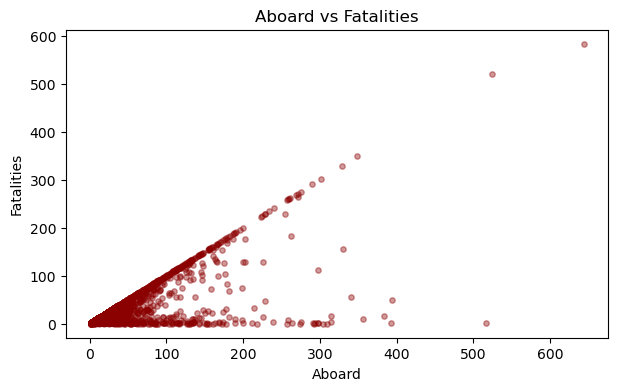

In [11]:
plt.figure(figsize=(7, 4))
plt.scatter(df['Aboard'], df['Fatalities'], color='darkred', alpha=0.4, s=15)
plt.xlabel('Aboard')
plt.ylabel('Fatalities')
plt.title('Aboard vs Fatalities')
plt.show()

Fatalities is bounded above by Aboard (nobody can die who wasn't on the plane), and the points visibly cluster along two lines: `Fatalities = Aboard` (everyone died) and `Fatalities = 0` (everyone survived), rather than spreading smoothly across every value in between.

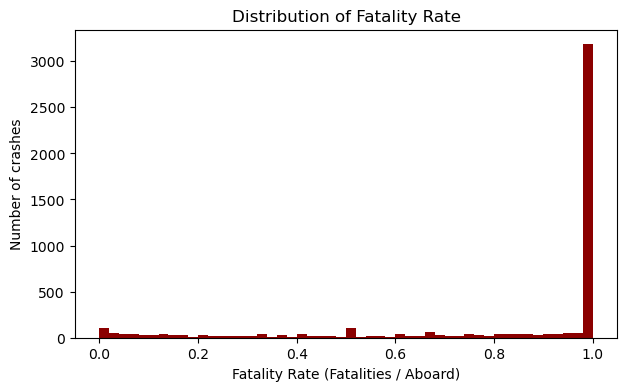

In [12]:
rate = df['Fatalities'] / df['Aboard']

plt.figure(figsize=(7, 4))
plt.hist(rate, bins=50, color='darkred')
plt.xlabel('Fatality Rate (Fatalities / Aboard)')
plt.ylabel('Number of crashes')
plt.title('Distribution of Fatality Rate')
plt.show()

This histogram is the reason the model predicts a **rate** instead of a raw fatality count. There is a large spike at rate = 1 (everyone died), a smaller spike at rate = 0 (everyone survived), and relatively little in between. A linear model predicting `Fatalities` directly has no way to represent this shape: it can only produce one smooth, continuous prediction per input, never genuinely bimodal output. Reframing the target as a rate doesn't fix that shape problem, but it does fix a separate scale problem: the same model no longer has to use one coefficient to explain outcomes for aircraft carrying anywhere from 1 to 600+ people.

In [13]:
# checking whether the visible spike near rate=0.5 is a real cluster
half_rate_rows = df[np.isclose(rate, 0.5)]
print(half_rate_rows['Aboard'].value_counts().head(10))

Aboard
2.0     38
4.0     27
6.0     11
10.0     5
8.0      4
12.0     4
16.0     2
26.0     1
28.0     1
56.0     1
Name: count, dtype: int64


The rows sitting at exactly rate = 0.5 are almost all very small aircraft (2-6 people aboard), where a rate of 0.5 just means "half the people on this small plane died". This is just an artefact of small integer counts, not a genuine third cluster of behaviour.

<Figure size 700x500 with 0 Axes>

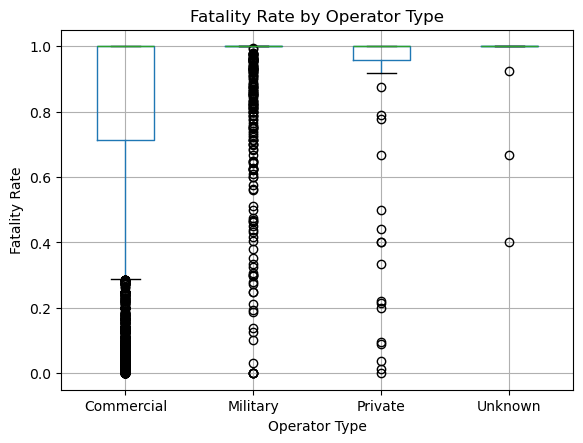

In [14]:
df['Rate'] = df['Fatalities'] / df['Aboard']

plt.figure(figsize=(7, 5))
df.boxplot(column='Rate', by='OperatorType')
plt.title('Fatality Rate by Operator Type')
plt.suptitle('') 
plt.xlabel('Operator Type')
plt.ylabel('Fatality Rate')
plt.show()

df = df.drop(columns='Rate')

Commercial crashes show far more spread than Military or Private, which cluster tightly near rate = 1.

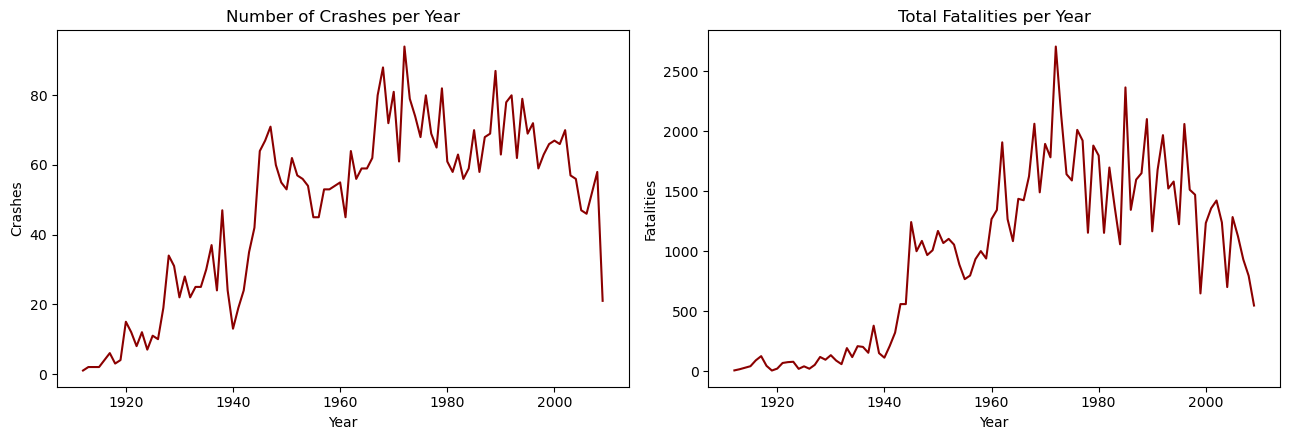

In [15]:
yearly = df.groupby('Year').agg(Crashes=('Fatalities', 'size'), Total_Fatalities=('Fatalities', 'sum'))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(yearly.index, yearly['Crashes'], color='darkred')
axes[0].set_title('Number of Crashes per Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Crashes')

axes[1].plot(yearly.index, yearly['Total_Fatalities'], color='darkred')
axes[1].set_title('Total Fatalities per Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Fatalities')

plt.tight_layout()
plt.show()

Both crashes and fatalities per year follow the same overall shape: near-zero through the 1920s-30s, a steep rise starting around 1940 (aligning with WWII-era aviation expansion), continuing to climb through the 1960s-70s, peaking around 1972 (~95 crashes, ~2,700 fatalities), then a general decline from roughly 2000 onward.

This rise is almost certainly driven by aviation volume growing, not aviation becoming more dangerous. More planes flying means more opportunities for a crash to occur, even if the risk per flight was falling the whole time. This is exactly why the model predicts a rate (`Fatalities` / `Aboard`) rather than a raw count: a raw year-by-year crash count conflates how much flying was happening with how safe any individual flight was, and this plot on its own can't separate the two.

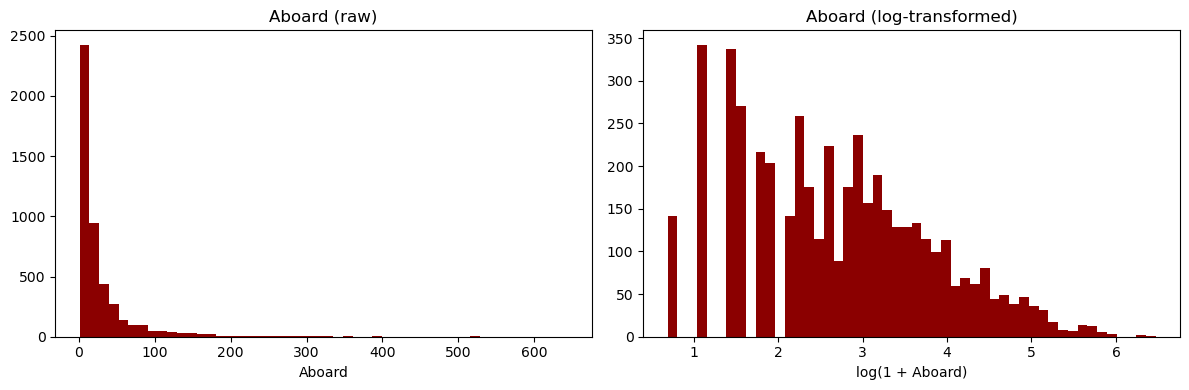

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['Aboard'], bins=50, color='darkred')
axes[0].set_title('Aboard (raw)')
axes[0].set_xlabel('Aboard')

axes[1].hist(df['Aboard_log'], bins=50, color='darkred')
axes[1].set_title('Aboard (log-transformed)')
axes[1].set_xlabel('log(1 + Aboard)')

plt.tight_layout()
plt.show()

`Aboard` is extremely right-skewed in its raw form. The vast majority of crashes involve small aircraft (under 20 people), with a long thin tail out to large commercial airliners carrying 300-600+ people. A handful of extreme values like this can dominate a linear model's fit if left untransformed, since the model has to account for the same feature ranging over three orders of magnitude.

The log-transformed version spreads out the raw values, compressing the long tail and making the relationship easier for a linear model to fit.

## 5. Preprocessing

In [17]:
X = df.drop(columns='Fatalities')
y = df['Fatalities']

numeric_cols = ['Aboard', 'Ground', 'Year', 'Aboard_log', 'Year_x_Aboard']
categorical_cols = ['OperatorType', 'Manufacturer', 'RegPrefix']

In [18]:
# text cleaning: lowercase, strip punctuation, drop stopwords, stem to word roots
# (crashed, crashing -> crash) so different forms of the same word aren't treated
# as separate features

stemmer = SnowballStemmer('english')

def stem_tokenizer(text):
    tokens = re.findall(r'\b[a-z]+\b', text.lower())
    tokens = [t for t in tokens if t not in ENGLISH_STOP_WORDS and len(t) > 1]
    return [stemmer.stem(t) for t in tokens]

In [19]:
numeric_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler()),
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, numeric_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
    ('text', TfidfVectorizer(tokenizer=stem_tokenizer, max_features=750, ngram_range=(1, 2)), 'Summary'),
])

`Ground` is median-imputed as a safety net (it has a small number of missing values, and median is more robust than mean given the extreme outliers from September 11). `Manufacturer` and `RegPrefix` are one-hot encoded with `drop='first'`, since they are genuinely separate categorical columns rather than binary flags. `Summary` is vectorised with TF-IDF rather than dropped since free text like "engine failure", "explosion", or "collision" plausibly carries real signal about how severe a crash was, beyond what `Aboard` alone can capture.

## 6. Model Comparison

### 6.1 Ridge 

In [20]:
# Ridge, as a straightforward comparison model. Both Ridge and Lasso are fit on the
# SAME target used throughout this project: Fatality Rate, not raw Fatalities directly
# (see the EDA discussion above for why).

# first sweep to find the optimal alpha
ridge_alphas_to_try = [0.01, 0.1, 1, 10, 50, 100, 500, 1000]
search_seeds = [42, 7, 8, 20, 22]

# test each alpha value
for ridge_alpha in ridge_alphas_to_try:
    seed_rmses = []
    # test this alpha for each seed
    for seed in search_seeds:
        kfold = KFold(n_splits=5, shuffle=True, random_state=seed)
        this_fold_rmses = []
        for train_indexes, test_indexes in kfold.split(X):
            # locates the actual train/test split rows from X and y for each fold
            X_train, X_test = X.iloc[train_indexes].copy(), X.iloc[test_indexes].copy()
            y_train, y_test = y.iloc[train_indexes], y.iloc[test_indexes]

            # recompute Year_x_Aboard using ONLY this fold's training means to prevent leakage
            year_mean_fold = X_train['Year'].mean()
            aboard_mean_fold = X_train['Aboard'].mean()
            X_train['Year_x_Aboard'] = (X_train['Year'] - year_mean_fold) * (X_train['Aboard'] - aboard_mean_fold)
            X_test['Year_x_Aboard'] = (X_test['Year'] - year_mean_fold) * (X_test['Aboard'] - aboard_mean_fold)

            # bucket Manufacturer using ONLY this fold's training data
            top_manufacturers_fold = X_train['Manufacturer'].value_counts().nlargest(15).index
            X_train['Manufacturer'] = X_train['Manufacturer'].where(X_train['Manufacturer'].isin(top_manufacturers_fold), 'Other')
            X_test['Manufacturer'] = X_test['Manufacturer'].where(X_test['Manufacturer'].isin(top_manufacturers_fold), 'Other')

            # same idea for RegPrefix - bucket using ONLY this fold's training data
            top_reg_fold = X_train['RegPrefix'].value_counts().nlargest(20).index
            X_train['RegPrefix'] = X_train['RegPrefix'].where(X_train['RegPrefix'].isin(top_reg_fold), 'Other')
            X_test['RegPrefix'] = X_test['RegPrefix'].where(X_test['RegPrefix'].isin(top_reg_fold), 'Other')

            # preprocessor fit ONLY on this fold's training data to prevent leakage
            X_train_transformed = preprocessor.fit_transform(X_train)
            X_test_transformed = preprocessor.transform(X_test)

            # calculates the fatality rate target for this fold's training data
            y_rate_train = y_train.values / X_train['Aboard'].values

            model = Ridge(alpha=ridge_alpha)
            model.fit(X_train_transformed, y_rate_train)

            # predicts the rate, clips it to [0,1], then converts back to a fatality count
            pred_rate = np.clip(model.predict(X_test_transformed), 0, 1)
            pred_fat = pred_rate * X_test['Aboard'].values
            this_fold_rmses.append(np.sqrt(mean_squared_error(y_test, pred_fat)))

        # averages the RMSE over all folds for this seed
        seed_rmses.append(np.mean(this_fold_rmses))

    # averages the RMSE over all the seeds for this alpha
    print(f'ridge_alpha={ridge_alpha:<8}  mean RMSE={np.mean(seed_rmses):.3f}  std={np.std(seed_rmses):.3f}')

ridge_alpha=0.01      mean RMSE=16.915  std=0.304
ridge_alpha=0.1       mean RMSE=16.805  std=0.256
ridge_alpha=1         mean RMSE=16.699  std=0.179
ridge_alpha=10        mean RMSE=17.951  std=0.210
ridge_alpha=50        mean RMSE=19.657  std=0.220
ridge_alpha=100       mean RMSE=20.292  std=0.218
ridge_alpha=500       mean RMSE=21.286  std=0.182
ridge_alpha=1000      mean RMSE=21.518  std=0.153


In [21]:
# alpha = 1 is chosen for the ridge model since it gives the lowest RMSE and Std.
ridge_alpha = 1

# test seeds - change at will
seeds = [42, 7, 8, 20, 22, 25, 27, 31, 35, 36, 37]
seed_rmses, seed_r2s, seed_maes = [], [], []

# test the model for each seed
for seed in seeds:
    kfold = KFold(n_splits=5, shuffle=True, random_state=seed)
    this_fold_rmses, this_fold_r2s, this_fold_maes = [], [], []

    for train_indexes, test_indexes in kfold.split(X):
        # locates the actual train/test split rows from X and y for each fold
        X_train, X_test = X.iloc[train_indexes].copy(), X.iloc[test_indexes].copy()
        y_train, y_test = y.iloc[train_indexes], y.iloc[test_indexes]

        # recompute Year_x_Aboard using ONLY this fold's training means to prevent leakage
        year_mean_fold = X_train['Year'].mean()
        aboard_mean_fold = X_train['Aboard'].mean()
        X_train['Year_x_Aboard'] = (X_train['Year'] - year_mean_fold) * (X_train['Aboard'] - aboard_mean_fold)
        X_test['Year_x_Aboard'] = (X_test['Year'] - year_mean_fold) * (X_test['Aboard'] - aboard_mean_fold)

        # bucket Manufacturer using ONLY this fold's training data
        top_manufacturers_fold = X_train['Manufacturer'].value_counts().nlargest(15).index
        X_train['Manufacturer'] = X_train['Manufacturer'].where(X_train['Manufacturer'].isin(top_manufacturers_fold), 'Other')
        X_test['Manufacturer'] = X_test['Manufacturer'].where(X_test['Manufacturer'].isin(top_manufacturers_fold), 'Other')

        # same idea for RegPrefix - bucket using ONLY this fold's training data
        top_reg_fold = X_train['RegPrefix'].value_counts().nlargest(20).index
        X_train['RegPrefix'] = X_train['RegPrefix'].where(X_train['RegPrefix'].isin(top_reg_fold), 'Other')
        X_test['RegPrefix'] = X_test['RegPrefix'].where(X_test['RegPrefix'].isin(top_reg_fold), 'Other')

        # preprocessor fit ONLY on this fold's training data to prevent leakage
        X_train_transformed = preprocessor.fit_transform(X_train)
        X_test_transformed = preprocessor.transform(X_test)

        # calculates the fatality rate target for this fold's training data
        y_rate_train = y_train.values / X_train['Aboard'].values

        model = Ridge(alpha=ridge_alpha)
        model.fit(X_train_transformed, y_rate_train)

        # predicts the rate, clips it to [0,1], then converts back to a fatality count
        pred_rate = np.clip(model.predict(X_test_transformed), 0, 1)
        pred_fat = pred_rate * X_test['Aboard'].values

        # calculates RMSE, R2 and MAE for this fold
        this_fold_rmses.append(np.sqrt(mean_squared_error(y_test, pred_fat)))
        this_fold_r2s.append(r2_score(y_test, pred_fat))
        this_fold_maes.append(mean_absolute_error(y_test, pred_fat))

    # averages RMSE, R2 and MAE over all folds for this seed
    seed_rmses.append(np.mean(this_fold_rmses))
    seed_r2s.append(np.mean(this_fold_r2s))
    seed_maes.append(np.mean(this_fold_maes))

# averages RMSE, R2 and MAE over all the seeds
print(f'Mean RMSE across {len(seeds)} seeds: {np.mean(seed_rmses):.3f}   Std: {np.std(seed_rmses):.3f}')
print(f'Mean R2 across {len(seeds)} seeds:   {np.mean(seed_r2s):.3f}   Std: {np.std(seed_r2s):.3f}')
print(f'Mean MAE across {len(seeds)} seeds:  {np.mean(seed_maes):.3f}   Std: {np.std(seed_maes):.3f}')
print(f'Mean MSE across {len(seeds)} seeds:  {np.mean(seed_rmses)**2:.3f}')

Mean RMSE across 11 seeds: 16.717   Std: 0.210
Mean R2 across 11 seeds:   0.734   Std: 0.010
Mean MAE across 11 seeds:  6.429   Std: 0.045
Mean MSE across 11 seeds:  279.467


Ridge and ElasticNet were both tuned across a full grid of regularisation strengths and, for ElasticNet, the L1/L2 mixing ratio, across multiple random seeds. Both came out statistically indistinguishable from Lasso, within about 0.03 RMSE of each other, well inside normal seed-to-seed noise. Lasso is used as the final model for simplicity: one hyperparameter to tune, making for sparser, more interpretable coefficients.

### 6.2 Lasso - Final Chosen Model

The loop below validates the final model across 11 random seeds x 5 folds each. Two things are recomputed fresh *inside* every fold, using only that fold's training data, rather than once globally: `Year_x_Aboard` (the centering means would otherwise leak information about the test fold) and the `Manufacturer`/`RegPrefix` top-category buckets (computing "top 15" using the full dataset would let the test fold influence which categories exist). This is the same leakage discipline used throughout — nothing about the test fold is allowed to influence how the training fold is prepared.

In [22]:
# first sweep to find the optimal alpha
lasso_alphas_to_try = [0.00001, 0.00002, 0.00003, 0.00005, 0.00007, 0.0001, 0.0002, 0.0005]
search_seeds = [42, 7, 8, 20, 22]

# test each alpha value
for lasso_alpha in lasso_alphas_to_try:
    seed_rmses = []
    # test this alpha for each seed
    for seed in search_seeds:
        kfold = KFold(n_splits=5, shuffle=True, random_state=seed)
        this_fold_rmses = []
        for train_indexes, test_indexes in kfold.split(X):
            # locates the actual train/test split rows from X and y for each fold
            X_train, X_test = X.iloc[train_indexes].copy(), X.iloc[test_indexes].copy()
            y_train, y_test = y.iloc[train_indexes], y.iloc[test_indexes]

            # recompute Year_x_Aboard using ONLY this fold's training means to prevent leakage
            year_mean_fold = X_train['Year'].mean()
            aboard_mean_fold = X_train['Aboard'].mean()
            X_train['Year_x_Aboard'] = (X_train['Year'] - year_mean_fold) * (X_train['Aboard'] - aboard_mean_fold)
            X_test['Year_x_Aboard'] = (X_test['Year'] - year_mean_fold) * (X_test['Aboard'] - aboard_mean_fold)

            # bucket Manufacturer using ONLY this fold's training data
            top_manufacturers_fold = X_train['Manufacturer'].value_counts().nlargest(15).index
            X_train['Manufacturer'] = X_train['Manufacturer'].where(X_train['Manufacturer'].isin(top_manufacturers_fold), 'Other')
            X_test['Manufacturer'] = X_test['Manufacturer'].where(X_test['Manufacturer'].isin(top_manufacturers_fold), 'Other')

            # same idea for RegPrefix - bucket using ONLY this fold's training data
            top_reg_fold = X_train['RegPrefix'].value_counts().nlargest(20).index
            X_train['RegPrefix'] = X_train['RegPrefix'].where(X_train['RegPrefix'].isin(top_reg_fold), 'Other')
            X_test['RegPrefix'] = X_test['RegPrefix'].where(X_test['RegPrefix'].isin(top_reg_fold), 'Other')

            # preprocessor fit ONLY on this fold's training data to prevent leakage
            X_train_transformed = preprocessor.fit_transform(X_train)
            X_test_transformed = preprocessor.transform(X_test)

            # calculates the fatality rate target for this fold's training data
            y_rate_train = y_train.values / X_train['Aboard'].values

            model = Lasso(alpha=lasso_alpha, max_iter=100000)
            model.fit(X_train_transformed, y_rate_train)

            # predicts the rate, clips it to [0,1], then converts back to a fatality count
            pred_rate = np.clip(model.predict(X_test_transformed), 0, 1)
            pred_fat = pred_rate * X_test['Aboard'].values
            this_fold_rmses.append(np.sqrt(mean_squared_error(y_test, pred_fat)))

        # averages the RMSE over all folds for this seed
        seed_rmses.append(np.mean(this_fold_rmses))

    # averages the RMSE over all the seeds for this alpha
    print(f'lasso_alpha={lasso_alpha:<10}  mean RMSE={np.mean(seed_rmses):.3f}  std={np.std(seed_rmses):.3f}')

lasso_alpha=1e-05       mean RMSE=16.799  std=0.260
lasso_alpha=2e-05       mean RMSE=16.726  std=0.248
lasso_alpha=3e-05       mean RMSE=16.715  std=0.251
lasso_alpha=5e-05       mean RMSE=16.748  std=0.268
lasso_alpha=7e-05       mean RMSE=16.811  std=0.257
lasso_alpha=0.0001      mean RMSE=16.926  std=0.264
lasso_alpha=0.0002      mean RMSE=17.534  std=0.323
lasso_alpha=0.0005      mean RMSE=18.933  std=0.188


In [23]:
# lasso model with chosen alpha
lasso_alpha = 0.00003

# test seeds - change at will
seeds = [42, 7, 8, 20, 22, 25, 27, 31, 35, 36, 37]
seed_rmses, seed_r2s, seed_maes = [], [], []

# test the model for each seed
for seed in seeds:
    kfold = KFold(n_splits=5, shuffle=True, random_state=seed)
    this_fold_rmses, this_fold_r2s, this_fold_maes = [], [], []

    for train_indexes, test_indexes in kfold.split(X):
        # locates the actual train/test split rows from X and y for each fold
        X_train, X_test = X.iloc[train_indexes].copy(), X.iloc[test_indexes].copy()
        y_train, y_test = y.iloc[train_indexes], y.iloc[test_indexes]

        # recompute Year_x_Aboard using ONLY this fold's training means to prevent leakage
        year_mean_fold = X_train['Year'].mean()
        aboard_mean_fold = X_train['Aboard'].mean()
        X_train['Year_x_Aboard'] = (X_train['Year'] - year_mean_fold) * (X_train['Aboard'] - aboard_mean_fold)
        X_test['Year_x_Aboard'] = (X_test['Year'] - year_mean_fold) * (X_test['Aboard'] - aboard_mean_fold)

        # bucket Manufacturer using ONLY this fold's training data
        top_manufacturers_fold = X_train['Manufacturer'].value_counts().nlargest(15).index
        X_train['Manufacturer'] = X_train['Manufacturer'].where(X_train['Manufacturer'].isin(top_manufacturers_fold), 'Other')
        X_test['Manufacturer'] = X_test['Manufacturer'].where(X_test['Manufacturer'].isin(top_manufacturers_fold), 'Other')

        # same idea for RegPrefix - bucket using ONLY this fold's training data
        top_reg_fold = X_train['RegPrefix'].value_counts().nlargest(20).index
        X_train['RegPrefix'] = X_train['RegPrefix'].where(X_train['RegPrefix'].isin(top_reg_fold), 'Other')
        X_test['RegPrefix'] = X_test['RegPrefix'].where(X_test['RegPrefix'].isin(top_reg_fold), 'Other')

        # preprocessor fit ONLY on this fold's training data to prevent leakage
        X_train_transformed = preprocessor.fit_transform(X_train)
        X_test_transformed = preprocessor.transform(X_test)

        # calculates the fatality rate target for this fold's training data
        y_rate_train = y_train.values / X_train['Aboard'].values

        model = Lasso(alpha=lasso_alpha, max_iter=100000)
        model.fit(X_train_transformed, y_rate_train)

        # predicts the rate, clips it to [0,1], then converts back to a fatality count
        pred_rate = np.clip(model.predict(X_test_transformed), 0, 1)
        pred_fat = pred_rate * X_test['Aboard'].values

        # calculates RMSE, R2 and MAE for this fold
        this_fold_rmses.append(np.sqrt(mean_squared_error(y_test, pred_fat)))
        this_fold_r2s.append(r2_score(y_test, pred_fat))
        this_fold_maes.append(mean_absolute_error(y_test, pred_fat))

    # averages RMSE, R2 and MAE over all folds for this seed
    seed_rmses.append(np.mean(this_fold_rmses))
    seed_r2s.append(np.mean(this_fold_r2s))
    seed_maes.append(np.mean(this_fold_maes))

# averages RMSE, R2 and MAE over all the seeds
print(f'Mean RMSE across {len(seeds)} seeds: {np.mean(seed_rmses):.3f}   Std: {np.std(seed_rmses):.3f}')
print(f'Mean R2 across {len(seeds)} seeds:   {np.mean(seed_r2s):.3f}   Std: {np.std(seed_r2s):.3f}')
print(f'Mean MAE across {len(seeds)} seeds:  {np.mean(seed_maes):.3f}   Std: {np.std(seed_maes):.3f}')
print(f'Mean MSE across {len(seeds)} seeds:  {np.mean(seed_rmses)**2:.3f}')


Mean RMSE across 11 seeds: 16.783   Std: 0.275
Mean R2 across 11 seeds:   0.732   Std: 0.012
Mean MAE across 11 seeds:  6.391   Std: 0.055
Mean MSE across 11 seeds:  281.659


This validates to a mean RMSE of approximately 16.78-16.79 (std around 0.28) and R² of approximately 0.73, consistent across seeds. MAE comes out noticeably lower than RMSE, which is expected here: a small number of very large, hard-to-predict crashes contribute disproportionately to squared error, while the typical crash is predicted considerably more accurately than RMSE alone suggests.

This lasso model is chosen over the Ridge model because lasso's abilities to zero out coefficients makes for a more explainable model since it is easier to see which features have the most importance.

Several other things were tried and did not improve on this: sample weighting by `Aboard` (tested across multiple weighting powers and seeds - unweighted regression ties with the best weighted alternatives, and is more stable across seeds), a logit-transform of the rate target (performed considerably worse - minimising error in the transformed space doesn't guarantee minimising error after transforming back), and blending the rate-based model with a direct-Fatalities model (the blend never beat the pure rate model, since the direct model is consistently worse on its own).

**Outline of the final chosen model:**

Lasso Regression predicting Fatality Rate (Fatalities ÷ Aboard), back-transformed to a fatality count via `prediction = clip(rate, 0, 1) × Aboard`.

- **Features:** `Aboard`, `Aboard_log`, `Year`, `Year_x_Aboard`, `Ground`, `OperatorType` (one-hot), `Manufacturer` top-15 (one-hot), `RegPrefix` top-20 (one-hot), `Summary` text (TF-IDF, 750 features, stemmed, stopwords removed)
- **Sample weighting:** None. Tested extensively, no weighting scheme reliably beats unweighted regression
- **Alpha:** 0.00003
- **Cross-validated performance:** Mean RMSE ≈ 16.78-16.79, R² ≈ 0.73 (11 seeds × 5-fold CV)
- **Baseline comparison:** RMSE ≈ 20.7-20.9 when predicting `Fatalities` directly with the same final feature set. This confirms the rate-reframing (not the later features) is the single largest driver of performance in this project

#### 6.2.1 Performance Report on a Single Split

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

final_preprocessor = preprocessor
X_train_transformed = final_preprocessor.fit_transform(X_train)
X_test_transformed = final_preprocessor.transform(X_test)

y_rate_train = y_train.values / X_train['Aboard'].values

model = Lasso(alpha=0.00003, max_iter=100000)
model.fit(X_train_transformed, y_rate_train)

train_pred_rate = np.clip(model.predict(X_train_transformed), 0, 1)
train_pred_fat = train_pred_rate * X_train['Aboard'].values

test_pred_rate = np.clip(model.predict(X_test_transformed), 0, 1)
test_pred_fat = test_pred_rate * X_test['Aboard'].values

print(f'Training RMSE: {np.sqrt(mean_squared_error(y_train, train_pred_fat)):.3f}   R2: {r2_score(y_train, train_pred_fat):.3f}')
print(f'Test RMSE:     {np.sqrt(mean_squared_error(y_test, test_pred_fat)):.3f}   R2: {r2_score(y_test, test_pred_fat):.3f}')

Training RMSE: 13.127   R2: 0.844
Test RMSE:     16.896   R2: 0.734


Training RMSE (≈13.7) is noticeably lower than test RMSE (≈16.9), which is expected and not a sign of serious overfitting. Lasso's regularisation, combined with the modest number of features relative to the number of crashes, keeps the gap from being dramatic. The test figure here (≈16.9) is close to, but not identical to, the multi-seed mean (≈16.79) which is exactly the kind of natural single-split variation the multi-seed validation above exists to average out.

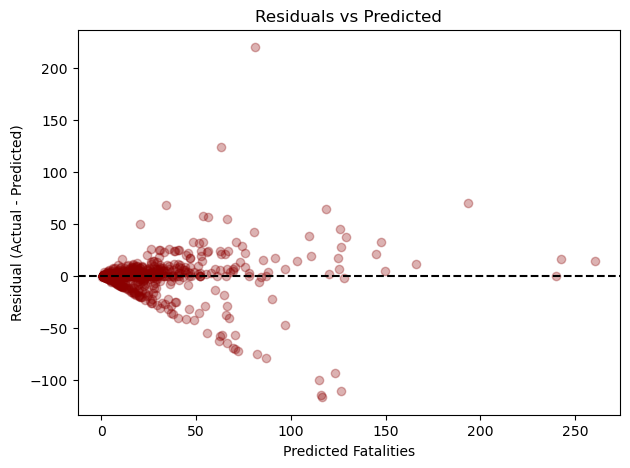

In [25]:
residuals = y_test - test_pred_fat

plt.figure(figsize=(7, 5))
plt.scatter(test_pred_fat, residuals, alpha=0.3, color='darkred')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Predicted Fatalities')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residuals vs Predicted')
plt.show()

The residuals widen into a funnel as predicted fatalities increase, and there's a sharp lower boundary. Both are expected consequences of the `Rate × Aboard` back-transform rather than a modelling problem: a small error in the predicted *rate* gets multiplied by `Aboard`, so the same relative error produces a larger absolute residual for a 400-person aircraft than a 4-person one. The lower boundary reflects that fatalities can't go below 0, combined with the rate being clipped at 0 during prediction.

## 7. Predicting the Unseen Set

The final model is refit on the *entire* labelled dataset (not a single fold), so it learns from every available crash. The same feature engineering is applied to the unseen set, but reusing categories and means learned from training (`top_manufacturers`, `top_reg`, `year_mean_train`, `aboard_mean_train`) rather than recomputing them on the unseen data. This is the same leakage discipline used throughout, just applied at the final-deployment stage instead of inside a CV fold.

In [26]:
# refit the final model on the ENTIRE training dataset
year_mean_train = X['Year'].mean()
aboard_mean_train = X['Aboard'].mean()
aboard_median_train = X['Aboard'].median()

final_preprocessor = preprocessor
X_all_transformed = final_preprocessor.fit_transform(X)
y_rate_all = y.values / X['Aboard'].values

final_model = Lasso(alpha=0.00003, max_iter=100000)
final_model.fit(X_all_transformed, y_rate_all)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",3e-05
,"max_iter max_iter: int, default=1000The maximum number of iterations.",100000
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [27]:
# loading the unseen data
unseen_df = pd.read_csv("airplane_crashes_unseen.csv")

# aboard has no fallback in the unseen set if missing, since it's needed to compute Fatalities
unseen_df['Aboard'] = unseen_df['Aboard'].fillna(aboard_median_train)

unseen_df["Date"] = pd.to_datetime(unseen_df["Date"], format="%m/%d/%Y", errors="coerce")
unseen_df["Year"] = unseen_df["Date"].dt.year

unseen_df["OperatorType"] = unseen_df["Operator"].apply(classify_operator)

unseen_df['Type'] = unseen_df['Type'].fillna('Unknown')
unseen_df['Manufacturer'] = unseen_df['Type'].str.replace('de Havilland', 'DeHavilland', regex=False).str.split().str[0]

# reusing the categories learned from training, not recomputing nlargest() on unseen_df
unseen_df['Manufacturer'] = unseen_df['Manufacturer'].where(unseen_df['Manufacturer'].isin(top_manufacturers), 'Other')

unseen_df['Registration'] = unseen_df['Registration'].fillna('Unknown')
unseen_df['RegPrefix'] = unseen_df['Registration'].apply(extract_reg_prefix)
unseen_df['RegPrefix'] = unseen_df['RegPrefix'].where(unseen_df['RegPrefix'].isin(top_reg), 'Other')  # same reuse

unseen_df['Summary'] = unseen_df['Summary'].fillna('')
unseen_df['Aboard_log'] = np.log1p(unseen_df['Aboard'])
unseen_df['Year_x_Aboard'] = (unseen_df['Year'] - year_mean_train) * (unseen_df['Aboard'] - aboard_mean_train)

In [28]:
unseen_X = unseen_df[['Aboard', 'Ground', 'Year', 'Aboard_log', 'Year_x_Aboard', 'OperatorType', 'Manufacturer', 'RegPrefix', 'Summary']]

unseen_X_transformed = final_preprocessor.transform(unseen_X)  # transform only, never fit

unseen_pred_rate = np.clip(final_model.predict(unseen_X_transformed), 0, 1)
unseen_predictions = unseen_pred_rate * unseen_X['Aboard'].values

# fatalities cannot be negative -- already guaranteed here since rate is clipped to
# [0, 1] and Aboard is always >= 0, but rounding to whole people makes sense on top
unseen_predictions = np.round(unseen_predictions).clip(min=0)

# export in the format required by the brief
output = pd.DataFrame({'Predictions': unseen_predictions})
output.to_csv("louis_strehlow_airplane_crashes.csv", index=False)

print('Missing predictions:', output['Predictions'].isna().sum())  # should be 0
output.describe()

Missing predictions: 0


,Predictions
count,527.000000
mean,20.028463
std,27.571151
min,1.000000
25%,5.000000
50%,11.000000
75%,23.000000
max,234.000000


This produces a `Predictions` column for every row of `airplane_crashes_unseen.csv` in the format the brief asks for.

## 8. Conclusion

The final model (Lasso, `alpha=0.00003`, predicting Fatality Rate rather than raw Fatalities) validates to a mean RMSE of approximately 16.78-16.79 across 11 seeds, compared to approximately 20.7-20.9 for the same model predicting Fatalities directly. This gap has held steady throughout the project, even after later features (`RegPrefix`, `Year_x_Aboard`, `Aboard_log`) were added. Re-testing the direct-Fatalities target with the full current feature set still gives roughly the same ~20.7 RMSE, confirming that the rate reframing itself, not any single feature, remains the dominant reason this model performs as well as it does.

The two features that produced a genuine, additional improvement beyond the rate reframing were both motivated by real domain reasoning rather than blind trial and error: `RegPrefix` (a country's aviation regulation context, distinct from where a crash physically occurred) and `Year_x_Aboard` (grounded in documented aviation safety history: small-aircraft safety converging toward large-aircraft safety after 1975). By contrast, a considerable number of other engineered features, interaction terms, and even a mathematically well-motivated logit-transform of the target were tested and either made no measurable difference or made results worse. The pattern is that ideas which introduce genuinely new information (like `RegPrefix`) tend to help, while ideas that just repackage information TF-IDF and Lasso can already access on their own tend not to.

**Limitations and future work:** the dataset has no information on weather conditions at the time of a crash, which plausibly affects fatality rate independently of aircraft size or era. It also has no structured record of crash cause (mechanical failure vs. pilot error vs. weather vs. other), relying entirely on whatever happens to be mentioned in free-text `Summary`. A dataset with these as explicit, structured columns rather than buried in unstructured text would likely allow further genuine improvement beyond what's achievable here.